# **1. Introduction**
Morphological analysis remains a starting cornerstone for hematological diagnostics, providing critical insights for detecting heamatological malignancy, and other blood related disorders. 
However, this process is inherently time consuming, subject to inter observer variability, and requires specialized expertise that may be unavailable in resource constrained settings.
tudies have documented significant disagreement rates even among experienced hematologists when classifying morphologically ambiguous cells, particularly in distinguishing blast populations or atypical lymphocytes [Matek et al., 2019].

The objective of this project is to design and develop an automatic blood cell type classification system.  


# 2. Data
## 2.1 Images datasets
This project integrates two complementary blood cell image datasets that together provide comprehensive coverage of both normal peripheral blood morphology and pathological cells associated with acute myeloid leukemia (AML).

Combining these datasets provides balanced representation across the morphological spectrum required for clinical blood cell classification:
The Mendeley dataset supplies robust representation of normal cell types essential for differential diagnosis
The TCIA AML dataset contributes pathological blast populations and rare immature precursors critical for leukemia detection
Together they enable training of models capable of distinguishing normal variants from malignant cells while recognizing ambiguous cases requiring expert review (e.g., atypical lymphocytes vs. blasts)


## 2.1.1 Mendeley Blood Cell Dataset
The first dataset comprises `17,092` microscopic images of normal peripheral blood cells obtained from the Hospital Clínic de Barcelona's Core Laboratory `[Acevedo et al., 2019]`. All images were captured using the CellaVision DM96 digital hematology analyzer at a resolution of 360 × 363 pixels in RGB JPG format.
Blood samples were collected from donors without infections, hematologic or oncologic diseases, and pharmaceutical treatments at the time of acquisition. Smears were stained using the standardized May-Grünwald-Giemsa protocol, ensuring consistent morphological visualization across samples.
The dataset encompasses eight morphological classes representing normal leukocyte populations and precursors:
1) Neutrophils (segmented and band forms)
2) Eosinophils
3) Immature granulocytes (metamyelocytes, myelocytes, and promyelocytes)
4) Platelet
5) Erythroblasts
6) Monocytes
7) Basophils
8) Lymphocytes (typical)
   
| Index | Cell Type     | count | percentage |
|-------|---------------|-------|------------|
| 0     | Neutrophil    | 3329  | 19.48      |
| 1     | Eosinophil    | 3117  | 18.24      |
| 2     | ig            | 2896  | 16.94      |
| 3     | Platelet      | 2348  | 13.74      |
| 4     | Erythroblast  | 1551  | 9.07       |
| 5     | Monocyte      | 1420  | 8.31       |
| 6     | Basophil      | 1218  | 7.13       |
| 7     | Lymphocyte    | 1214  | 7.10       |

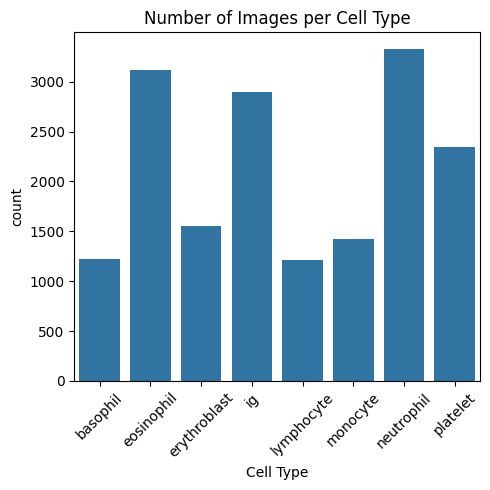

In [7]:
#Plot Class Distribution 
plt.figure(figsize=(5, 5))
sns.barplot(data=df_counts, x="Cell Type", y="count")
plt.xticks(rotation=45)
plt.title("Number of Images per Cell Type")
plt.tight_layout()
plt.show()

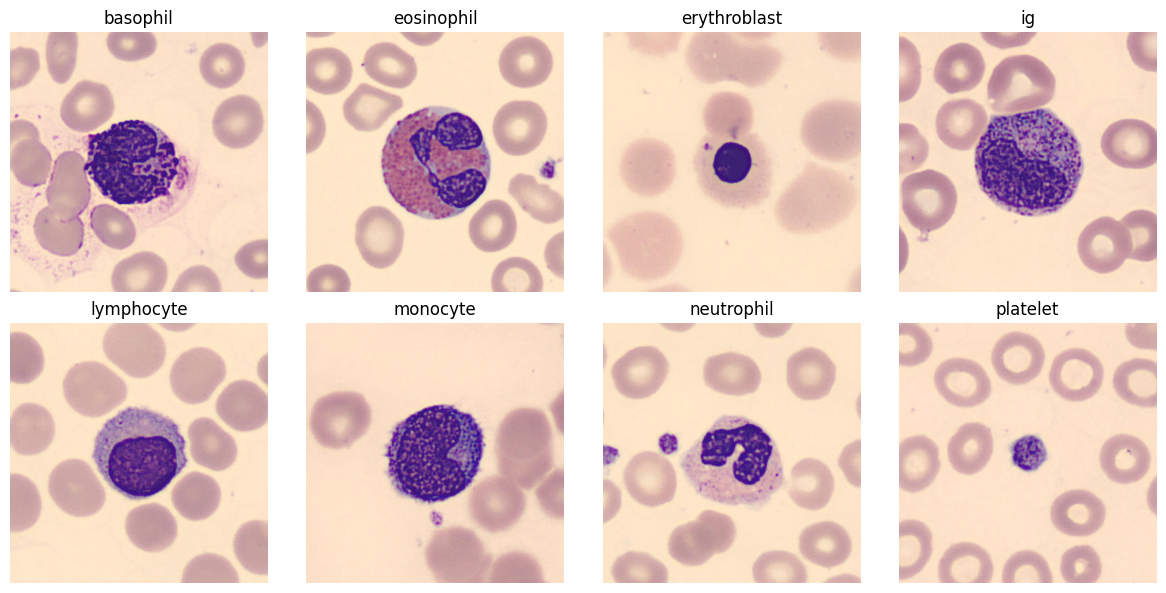

In [8]:
#Show Sample Images 
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i, cls in enumerate(classes):
    img_path = list((DATA_DIR / cls).glob("*"))[0]  # first image
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 2.1.2 The Cancer Imaging Archive (TCIA) AML Dataset
The second dataset contains `18,365` single-cell images extracted from peripheral blood smears of 200 individuals: 100 patients diagnosed with various subtypes of acute myeloid leukemia (AML) and 100 patients exhibiting no morphological features of hematological malignancies [Matek et al., 2019]. 
Each cropped image represents a single white blood cell and was assigned a label according to clinically relevant cytomorphological categories used in hematology diagnostics. The dataset includes mature leukocytes, immature granulocyte precursors, and pathological cell types such as myeloblasts, which are crucial for AML diagnosis. The images reflect real clinical variability, including staining differences, background artifacts, and class imbalance, making the dataset particularly suitable for developing robust computer vision models for blood cell classification and leukemia screening tasks.


| index | cell_type               | count | frequency |
|-------|-------------------------|-------|-----------|
| 0     | Neutrophil (segmented)  | 8484  | 46.20     |
| 1     | Lymphocyte (typical)    | 3937  | 21.44     |
| 2     | Myeloblast              | 3268  | 17.79     |
| 3     | Monocyte                | 1789  | 9.74      |
| 4     | Eosinophil              | 424   | 2.31      |
| 5     | Neutrophil (band)       | 109   | 0.59      |
| 6     | Basophil                | 79    | 0.43      |
| 7     | Erythroblast            | 78    | 0.42      |
| 8     | Promyelocyte            | 70    | 0.38      |
| 9     | Myelocyte               | 42    | 0.23      |
| 10    | Monoblast               | 26    | 0.14      |
| 11    | Promyelocyte (bilobed)  | 18    | 0.10      |
| 12    | Smudge cell             | 15    | 0.08      |
| 13    | Metamyelocyte           | 15    | 0.08      |
| 14    | Lymphocyte (atypical)   | 11    | 0.06      |

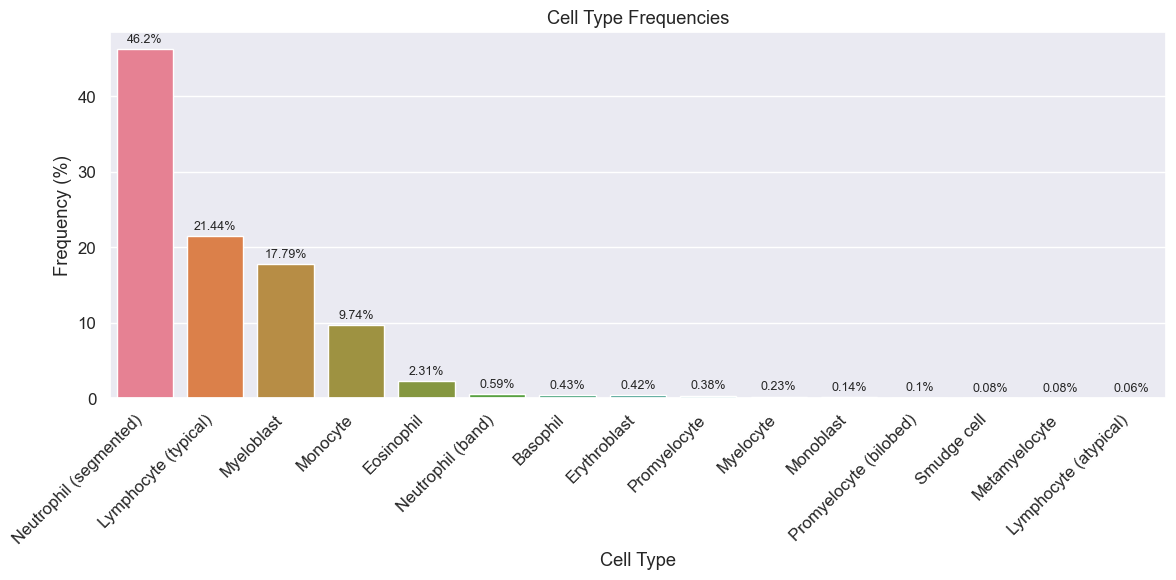

In [139]:

sns.set_style("darkgrid")
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='cell_type', hue='cell_type', y='frequency', data=data, palette='husl', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Cell Type Frequencies')
plt.ylabel('Frequency (%)')
plt.xlabel('Cell Type')

# value labels for each column
for i, v in enumerate(data['frequency']):
    ax.text(i, v + 0.5, f'{v}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

A subset of 1,905 single-cell images was re-annotated by a same examiner (using only cropped cell images, without smear context). The re-annotation was performed twice, with an 11 months gap, allowing assessment of both inter- and intra-examiner agreement.

The examiner could label images as “unclear” (63 images in the first pass, 208 in the second), reflecting uncertainty in some cases. For clearly assigned labels, agreement with the gold standard was excellent (Cohen’s κ = 0.84 and 0.87). thus to mention that some classification challenges are inherent to human cytomorphology rather than model limitations.

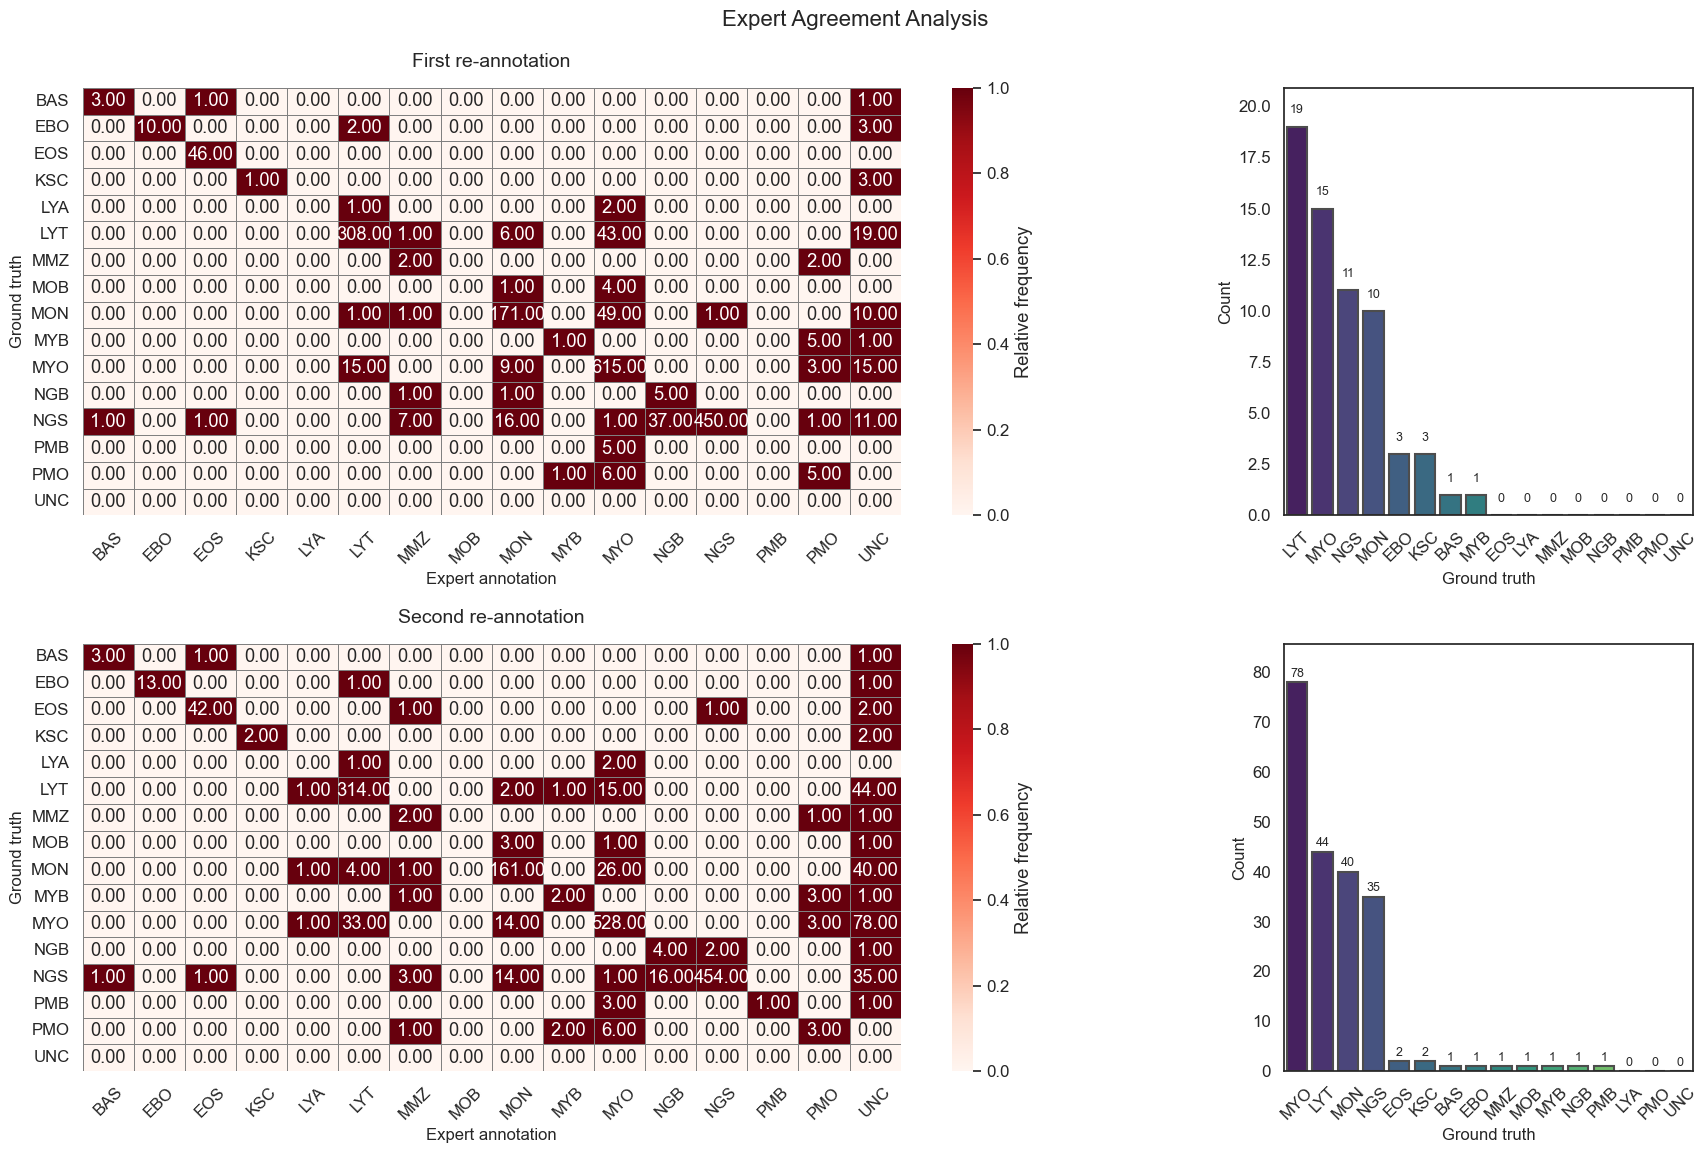

In [117]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have both crosstabs:
crosstab1 = pd.crosstab(first_expert.GS, first_expert["1_anno"])
crosstab2 = pd.crosstab(second_expert.GS, second_expert["2_anno"])

# Get complete label set from both crosstabs
all_labels = sorted(
    set(crosstab1.index) | set(crosstab1.columns) |
    set(crosstab2.index) | set(crosstab2.columns)
)

# Ensure 'UNC' is in all labels (add if missing)
if 'UNC' not in all_labels:
    all_labels.append('UNC')

# Reindex both crosstabs to have consistent 15x15 structure
crosstab1 = crosstab1.reindex(index=all_labels, columns=all_labels, fill_value=0)
crosstab2 = crosstab2.reindex(index=all_labels, columns=all_labels, fill_value=0)

# Create 2x2 grid figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12), 
                         gridspec_kw={'width_ratios': [2.5, 1]})

# ===== TOP ROW: FIRST RE-ANNOTATION =====
# Heatmap (top-left)
#crosstab1_norm = crosstab1.div(crosstab1.sum(axis=1), axis=0).fillna(0)
sns.heatmap(
    crosstab1,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=1,
    ax=axes[0, 0],
    cbar_kws={'label': 'Relative frequency'},
    linewidths=0.5,
    linecolor='gray'
)
axes[0, 0].set_title('First re-annotation', fontsize=14, pad=15)
axes[0, 0].set_xlabel('Expert annotation', fontsize=12)
axes[0, 0].set_ylabel('Ground truth', fontsize=12)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].tick_params(axis='y', rotation=0)

# Bar plot (top-right)
unc1 = crosstab1['UNC'].sort_values(ascending=False)
sns.barplot(
    x=unc1.index,
    hue=unc1.index,
    legend= False,
    y=unc1.values,
    ax=axes[0, 1],
    palette="viridis",
    edgecolor=".3",
    linewidth=1.5
)
for i, v in enumerate(unc1.values):
    axes[0, 1].text(i, v + 0.5, str(int(v)), 
                    ha='center', va='bottom', fontsize=9)
axes[0, 1].set_title('', pad=15)
axes[0, 1].set_xlabel('Ground truth', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_ylim(0, max(unc1.values) * 1.1)

# ===== BOTTOM ROW: SECOND RE-ANNOTATION =====
# Heatmap (bottom-left)
#crosstab2_norm = crosstab2.div(crosstab2.sum(axis=1), axis=0).fillna(0)
sns.heatmap(
    crosstab2,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    vmin=0,
    vmax=1,
    ax=axes[1, 0],
    cbar_kws={'label': 'Relative frequency'},
    linewidths=0.5,
    linecolor='gray'
)
axes[1, 0].set_title('Second re-annotation', fontsize=14, pad=15)
axes[1, 0].set_xlabel('Expert annotation', fontsize=12)
axes[1, 0].set_ylabel('Ground truth', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].tick_params(axis='y', rotation=0)

# Bar plot (bottom-right)
unc2 = crosstab2['UNC'].sort_values(ascending=False)
sns.barplot(
    x=unc2.index,
    y=unc2.values,
    ax=axes[1, 1],
    palette="viridis",
    legend=False,
    hue= unc2.index,
    edgecolor=".3",
    linewidth=1.5
)
for i, v in enumerate(unc2.values):
    axes[1, 1].text(i, v + 0.5, str(int(v)), 
                    ha='center', va='bottom', fontsize=9)
axes[1, 1].set_title('', pad=15)
axes[1, 1].set_xlabel('Ground truth', fontsize=12)
axes[1, 1].set_ylabel('Count', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].set_ylim(0, max(unc2.values) * 1.1)

# ===== FINAL FORMATTING =====
plt.tight_layout(pad=3.0)
plt.subplots_adjust(hspace=0.3, wspace=0.25)
plt.suptitle('Expert Agreement Analysis', fontsize=16, y=0.99)
plt.show()

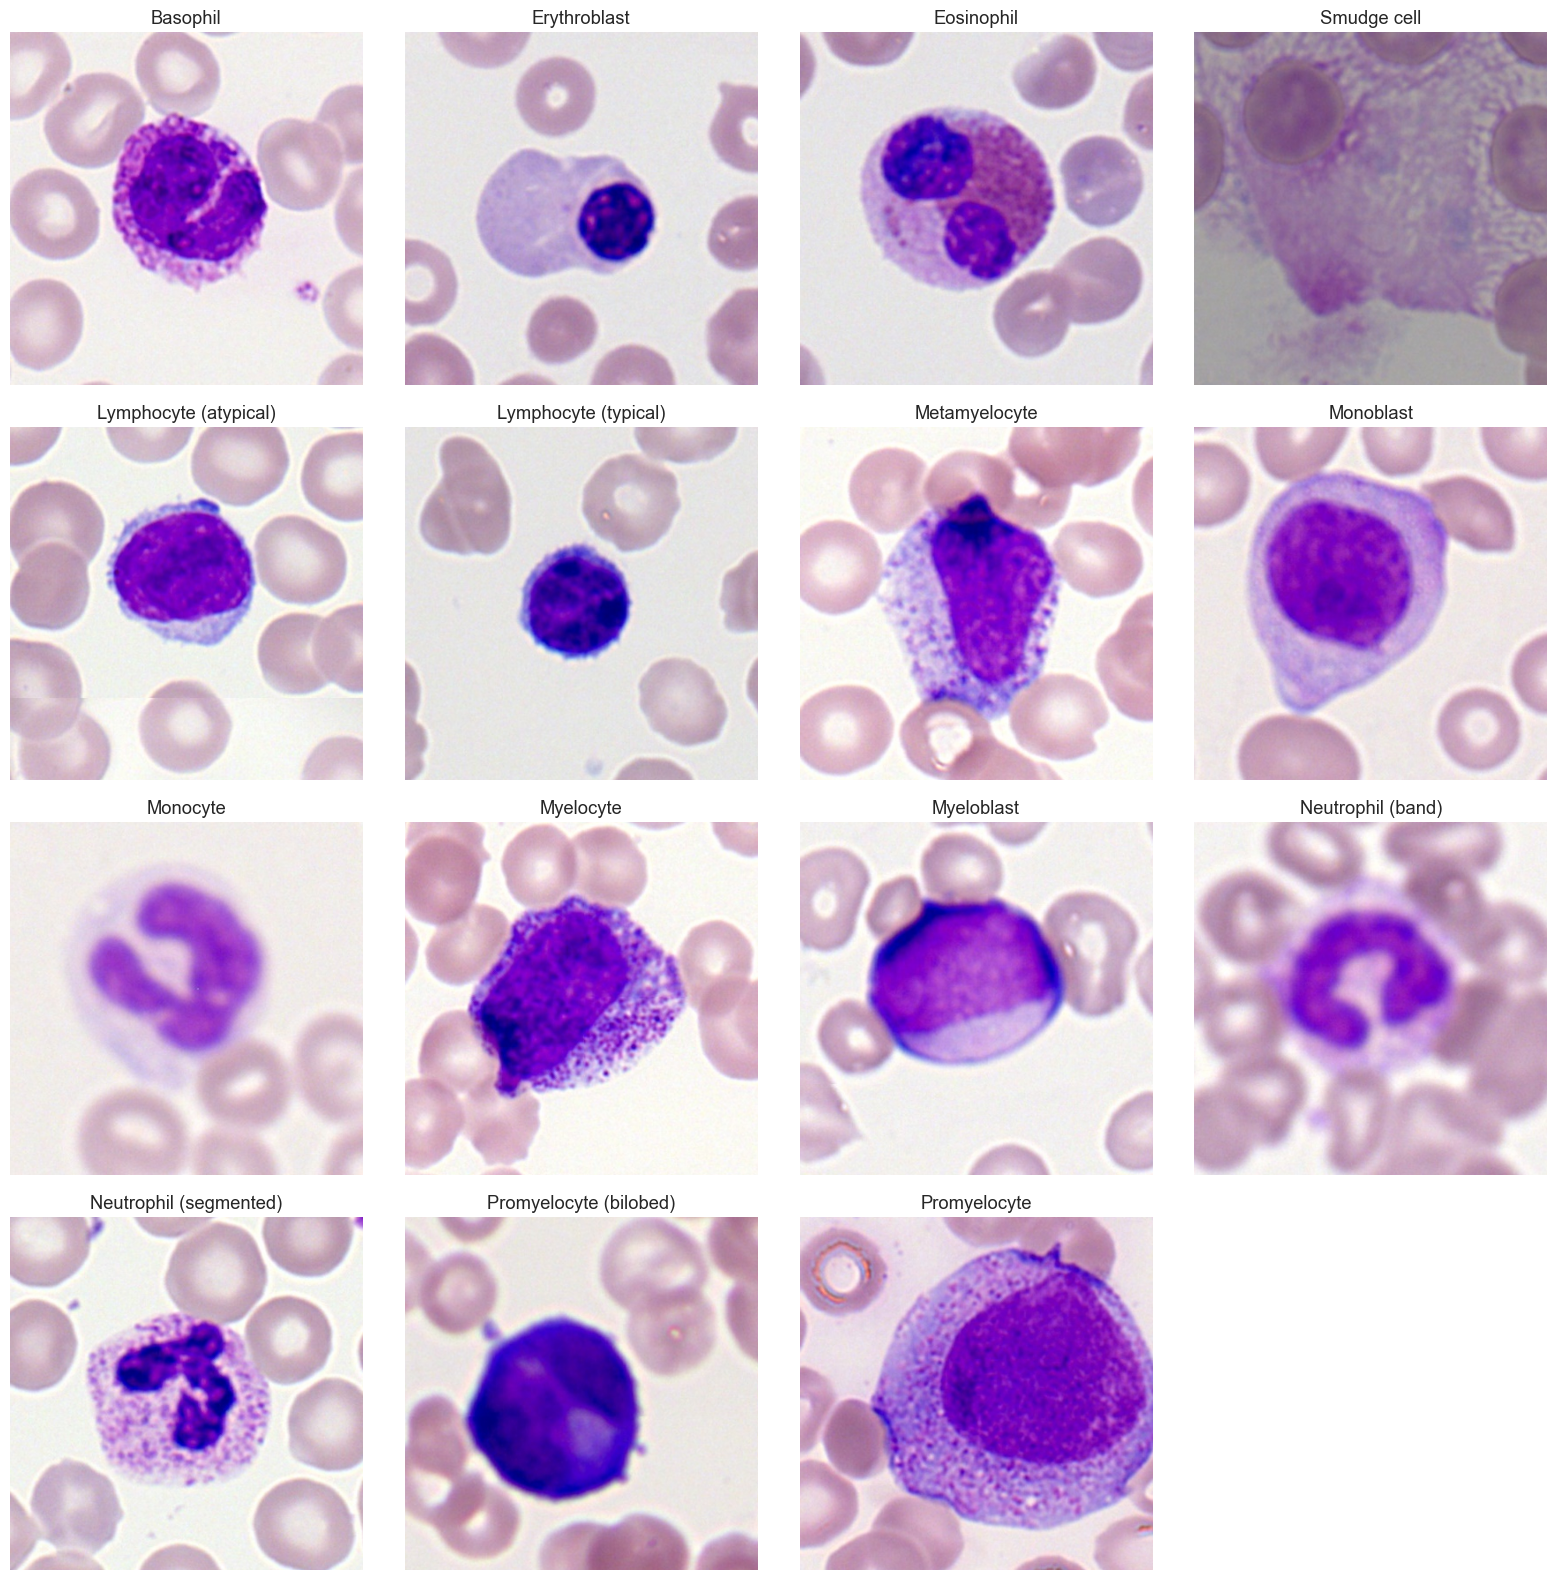

In [155]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image

# Dataset root
DATASET_DIR = Path("data/raw/PKG_AML_Cytomorphology_LMU")

def pick_one_image_per_class(dataset_dir, label_map):
    samples = []

    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        cell_code = class_dir.name
        cell_name = label_map.get(cell_code, cell_code)

        image_files = [
            p for p in class_dir.iterdir()
            if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".tif", ".tiff"}
        ]

        if not image_files:
            continue

        chosen_image = random.choice(image_files)
        samples.append((cell_name, chosen_image))

    return samples


def show_samples(samples, cols=4):
    rows = (len(samples) + cols - 1) // cols
    plt.figure(figsize=(16, 4 * rows))

    for i, (label, img_path) in enumerate(samples, start=1):
        plt.subplot(rows, cols, i)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# ---- run ----
samples = pick_one_image_per_class(DATASET_DIR, cell_codes)
show_samples(samples)
